##  Практическая 2, вариант 6

Задание 1

Найденные интервалы с корнями:
Корень 1: [-0.95, -0.88]
Корень 2: [0.27, 0.33]


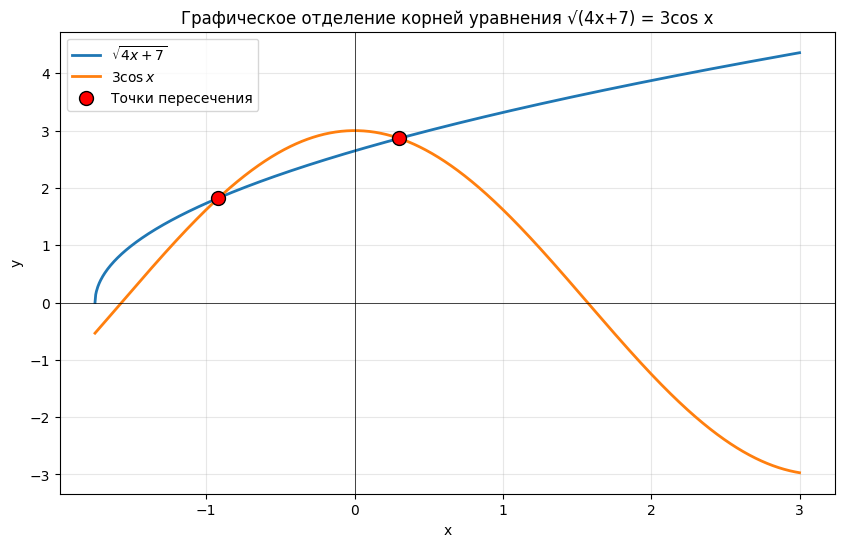


Найдено 2 корня


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_functions():
    x = np.linspace(-1.75, 3, 1000)
    y1 = np.sqrt(4*x + 7)
    y2 = 3 * np.cos(x)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y1, label=r'$\sqrt{4x+7}$', linewidth=2)
    plt.plot(x, y2, label=r'$3\cos x$', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Графическое отделение корней уравнения √(4x+7) = 3cos x')
    
    #  нахождение точки пересечения (где разность функций близка к нулю)
    diff = np.abs(y1 - y2)
    threshold = 0.05  # порог для определения близости к пересечению
    intersect_indices = np.where(diff < threshold)[0]
    
    #  группировка близких индексов в отдельные точки
    intersection_points = []
    used = set()
    intervals = []
    
    for idx in intersect_indices:
        if idx not in used:
            #  сбор кластера близких индексов
            cluster = [idx]
            used.add(idx)
            j = idx + 1
            while j in intersect_indices and j not in used:
                cluster.append(j)
                used.add(j)
                j += 1
            
            #  средняя точка кластера как точка пересечения
            if cluster:
                avg_idx = int(np.mean(cluster))
                x_intersect = x[avg_idx]
                y_intersect = (y1[avg_idx] + y2[avg_idx]) / 2
                intersection_points.append((x_intersect, y_intersect))
                
                #  нахождение интервала для корня
                left = x[cluster[0]]
                right = x[cluster[-1]]
                intervals.append((round(left,2), round(right,2)))
    
    #  отображение точек пересечения на графике 
    if intersection_points:
        xs, ys = zip(*intersection_points)
        plt.scatter(xs, ys, color='red', s=100, zorder=5, 
                   label='Точки пересечения', edgecolors='black')
    
    plt.legend()
    
    print("Найденные интервалы с корнями:")
    for i, (a, b) in enumerate(intervals, 1):
        print(f"Корень {i}: [{a}, {b}]")
    
    plt.show()
    return intervals

if __name__ == "__main__":
    intervals = plot_functions()
    
    #  уравнение
    def equation(x):
        return np.sqrt(4*x + 7) - 3*np.cos(x)
    
    if intervals:
        print(f"\nНайдено {len(intervals)} корня")
        
    else:
        print("Корни не найдены. Проверьте диапазон построения графика.")

Задание 2

In [29]:
def bisection_table(f, a, b, tol=1e-3, max_iter=100):
    print(f"Интервал: [{a}, {b}]")
    print(f"Точность: {tol}\n")
    
    if f(a) * f(b) >= 0:
        print("Ошибка: на концах интервала функция должна иметь разные знаки.")
        return None
    
    #  вывод таблицей(итерации)
    table_data = []
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        
        table_data.append({
            'n': i,
            'a': round(a, 6),
            'b': round(b, 6),
            'c': round(c, 6),
            'f(c)': round(fc, 6),
            '|b-a|': round(b - a, 6)
        })
        
        if (b - a) / 2 < tol or abs(fc) < tol:
            break
            
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    root = c
    print(f"Корень: {root:.6f}")
    print(f"Проверка: √(4·{root:.6f}+7) = {np.sqrt(4*root+7):.6f}")
    print(f"3cos({root:.6f}) = {3*np.cos(root):.6f}")
    
    return root

if __name__ == "__main__":        
        bisection_table(equation, a, b, tol=1e-3)

Интервал: [-0.92, -0.91]
Точность: 0.001

 n       a      b        c      f(c)  |b-a|
 0 -0.9200 -0.910 -0.91500 -0.001805 0.0100
 1 -0.9200 -0.915 -0.91750  0.001407 0.0050
 2 -0.9175 -0.915 -0.91625 -0.000200 0.0025
Корень: -0.916250
Проверка: √(4·-0.916250+7) = 1.826198
3cos(-0.916250) = 1.826398


##  Практическая 3, вариант 6

Задание 1

In [24]:
def phi(x):
    arg = np.sqrt(4*x + 7) / 3
    #  защита от выхода за [-1, 1] из-за погрешностей
    arg = np.clip(arg, -1, 1)
    return np.arccos(arg)

def fixed_point_iteration_table(x0, tol=1e-3, max_iter=100):
    print("Метод простых итераций для уравнения √(4x+7) = 3cos x")
    print("Итерационная функция: x = arccos( √(4x+7)/3 )")
    print(f"Начальное приближение: x0 = {x0}")
    print(f"Точность: {tol}\n")
    
    table_data = []
    x = x0
    
    for n in range(max_iter):
        x_new = phi(x)
        diff = abs(x_new - x)
        
        table_data.append({
            'n': n,
            'x_n': round(x, 6),
            'x_{n+1}': round(x_new, 6),
            '|x_{n+1}-x_n|': round(diff, 6)
        })
        
        if diff < tol:
            break
        x = x_new
    
    #  вывод таблицы(итерации)
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    #  зезультат
    root = x_new
    print(f"\nКорень: {root:.6f}")
    print(f"Проверка: √(4·{root:.6f}+7) = {np.sqrt(4*root+7):.6f}")
    print(f"3cos({root:.6f}) = {3*np.cos(root):.6f}")
    
    return root

#  начальное приближение (из графического анализа)
fixed_point_iteration_table(-0.9)

Метод простых итераций для уравнения √(4x+7) = 3cos x
Итерационная функция: x = arccos( √(4x+7)/3 )
Начальное приближение: x0 = -0.9
Точность: 0.001

 n       x_n  x_{n+1}  |x_{n+1}-x_n|
 0 -0.900000 0.908872       1.808872
 1  0.908872 0.000000       0.908872
 2  0.000000 0.490883       0.490883
 3  0.490883 0.063700       0.427183
 4  0.063700 0.455993       0.392293
 5  0.455993 0.140313       0.315679
 6  0.140313 0.411327       0.271014
 7  0.411327 0.199848       0.211479
 8  0.199848 0.373892       0.174044
 9  0.373892 0.239014       0.134878
10  0.239014 0.347532       0.108518
11  0.347532 0.263348       0.084185
12  0.263348 0.330285       0.066938
13  0.330285 0.278218       0.052067
14  0.278218 0.319359       0.041141
15  0.319359 0.287281       0.032078
16  0.287281 0.312540       0.025258
17  0.312540 0.292811       0.019729
18  0.292811 0.308315       0.015504
19  0.308315 0.296191       0.012124
20  0.296191 0.305708       0.009517
21  0.305708 0.298260       0.007448

np.float64(0.30190537809841506)

##  Практическая 4, вариант 6

Задание 1

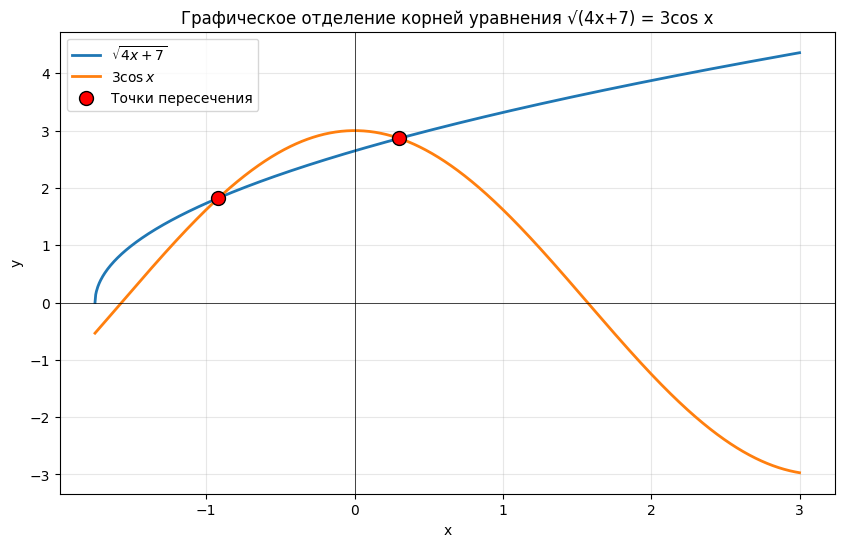

Найденные интервалы с корнями:
Корень 1: [-0.92, -0.91]
Корень 2: [0.3, 0.3]

Выбран интервал для уточнения: [-0.92, -0.91]


In [ ]:
#  уравнение f(x) = 0
def f(x):
    return np.sqrt(4*x + 7) - 3*np.cos(x)

#  производная для метода касательных
def f_prime(x):
    return 2 / np.sqrt(4*x + 7) + 3*np.sin(x)

#  функция для построения графика
def separate_roots():
    x_vals = np.linspace(-1.75, 3, 1000)
    y1 = np.sqrt(4*x_vals + 7)
    y2 = 3 * np.cos(x_vals)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y1, label=r'$\sqrt{4x+7}$', linewidth=2)
    plt.plot(x_vals, y2, label=r'$3\cos x$', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Графическое отделение корней уравнения √(4x+7) = 3cos x')
    
    #  нахождение интервалов, где графики пересекаются
    diff = y1 - y2
    signs = np.sign(diff)
    intervals = []
    for i in range(len(x_vals)-1):
        if signs[i] * signs[i+1] <= 0:
            intervals.append((round(x_vals[i],2), round(x_vals[i+1],2)))
    
    #  выделение?(отделение?) точки пересечения (где разность близка к нулю)
    tol_intersect = 0.05
    intersect_idx = np.where(np.abs(diff) < tol_intersect)[0]
    
    #  группировка близких индексов
    used = set()
    points = []
    for idx in intersect_idx:
        if idx not in used:
            cluster = [idx]
            used.add(idx)
            j = idx + 1
            while j in intersect_idx and j not in used:
                cluster.append(j)
                used.add(j)
                j += 1
            avg_idx = int(np.mean(cluster))
            points.append((x_vals[avg_idx], (y1[avg_idx] + y2[avg_idx])/2))
    
    if points:
        xs, ys = zip(*points)
        plt.scatter(xs, ys, color='red', s=100, zorder=5,
                   label='Точки пересечения', edgecolors='black')
    
    plt.legend()
    plt.show()
    
    print("Найденные интервалы с корнями:")
    for i, (a, b) in enumerate(intervals, 1):
        print(f"Корень {i}: [{a}, {b}]")
    
    return intervals
if __name__ == "__main__":
    intervals = separate_roots()
    
    if intervals:
        #  берём первый корень (около -0.916)
        a, b = intervals[0]
        print(f"\nВыбран интервал для уточнения: [{a}, {b}]")
    
    else:
        print("Корни не найдены.")

Задание 2

In [ ]:
def chord_method(f, a, b, tol=1e-3, max_iter=100):
    print(f"Интервал: [{a}, {b}]")
    print(f"Точность: {tol}\n")
    
    #  проверка на разные знаки в конце интервалов
    if f(a) * f(b) >= 0:
        print("Ошибка: на концах интервала функция должна иметь разные знаки.")
        return None
    
    #  пустой список для вывода итераций(а-левая граница;б-правая граница)
    table_data = []
    x_prev = a
    x_curr = b
    
    for n in range(max_iter):
        #  формула метода хорд
        x_next = x_curr - f(x_curr) * (x_curr - x_prev) / (f(x_curr) - f(x_prev))
        
        #  запись в список
        table_data.append({
            'n': n,
            'a': round(x_prev, 6),
            'b': round(x_curr, 6),
            'x_{n+1}': round(x_next, 6),
            'f(x_{n+1})': round(f(x_next), 6),
            '|x_{n+1}-x_n|': round(abs(x_next - x_curr), 6)
        })
        
        #  проверка на точность
        if abs(x_next - x_curr) < tol or abs(f(x_next)) < tol:
            break

        #  подготовка к следующей итерации    
        x_prev, x_curr = x_curr, x_next
    
    #   вывод результатов
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    root = x_next
    print(f"\nКорень (метод хорд): {root:.6f}")
    print(f"Проверка: f({root:.6f}) = {f(root):.2e}")
    return root

if __name__ == "__main__":
    
    if intervals:
        chord_method(f, a, b, tol=1e-3)
        
    else:
        print("Корни не найдены.")

Интервал: [-0.92, -0.91]
Точность: 0.001

 n     a     b   x_{n+1}  f(x_{n+1})  |x_{n+1}-x_n|
 0 -0.92 -0.91 -0.916395   -0.000014       0.006395

Корень (метод хорд): -0.916395
Проверка: f(-0.916395) = -1.35e-05


Задание 3

In [ ]:
def newton_method(f, fp, x0, tol=1e-3, max_iter=100):
    print(f"Начальное приближение: x0 = {x0}")
    print(f"Точность: {tol}\n")
    
    #  создание пустого списка
    table_data = []
    x = x0
    
    for n in range(max_iter):
        #  формула ньютона
        x_next = x - f(x) / fp(x)
        
        #  запись в список
        table_data.append({
            'n': n,
            'x_n': round(x, 6),
            'x_{n+1}': round(x_next, 6),
            'f(x_n)': round(f(x), 6),
            "f'(x_n)": round(fp(x), 6),
            '|x_{n+1}-x_n|': round(abs(x_next - x), 6)
        })
        
        #  проверка и подготовка к следующей итерации
        if abs(x_next - x) < tol or abs(f(x_next)) < tol:
            break    
        x = x_next

    #   вывод результатов
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    root = x_next
    print(f"\nКорень (метод Ньютона): {root:.6f}")
    print(f"Проверка: f({root:.6f}) = {f(root):.2e}")
    return root
if __name__ == "__main__":
    
    if intervals:
        x0 = (a + b) / 2  
        newton_method(f, f_prime, x0, tol=1e-3)
    else:
        print("Корни не найдены.")

Начальное приближение: x0 = -0.915
Точность: 0.001

 n    x_n   x_{n+1}    f(x_n)   f'(x_n)  |x_{n+1}-x_n|
 0 -0.915 -0.916407 -0.001805 -1.283336       0.001407

Корень (метод Ньютона): -0.916407
Проверка: f(-0.916407) = 1.16e-06
